# LOAD LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import save_parquet, load_parquet
from datetime import datetime
import os
import sys
import shap
# Custom utilities
# Add the parent directory (project root) to sys.path
# "Go up two levels" and add to path
sys.path.append(os.path.abspath('../../../')) 
from src.config import PERIOD_START, PERIOD_END, select_period
from src.gapfilling_utils import (
    fit_gapfill_ts,
    build_df_for_parcel,
    apply_gapfill_ts,
    plot_gapfill_dashboard,
    merge_gapfill_results
)

# CONFIGURATION

In [2]:
START_DATE, END_DATE = PERIOD_START, PERIOD_END  # dataset period, see src/config.py
TARGET_FLUX = 'NEE'
RAND_ERR_COL = "FC_RANDUNC_HF"  # EddyPro random uncertainty col
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
PARCEL_CERTAIN = True
LOG_TRANSFORM = False
UNDERSAMPLE = False
ADD_TRT = True
SHAP_CHECK = True

# LOAD DATA

In [3]:
data_main = fluxes = load_parquet(filepath=r"81.1.1_GapFillingDataset.parquet")
data_main = select_period(data_main, timestamp='middle')

# Make a copy of the original data for later use
maindf = data_main.copy()

# Keep only data where we are sure about parcel attribution
if PARCEL_CERTAIN:
    data_main = data_main[data_main['parcel_certainty'] == 'certain'].copy()
    print('\nKeeping only data when we are highly confident on the parcel attribution')
else:
    print('\nKeeping also data from mixed parcel contribution')

data_main

Loaded .parquet file 81.1.1_GapFillingDataset.parquet (0.078 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
select_period: kept 13776 of 13776 records (2024-08-22 00:15:00 to 2025-06-04 23:45:00, timestamp=middle)

Keeping only data when we are highly confident on the parcel attribution


,NEE_L3.3_CUT_16_QCF,NEE_L3.3_CUT_50_QCF,NEE_L3.3_CUT_84_QCF,NEE_L3.3_CUT_16_QCF0,NEE_L3.3_CUT_50_QCF0,NEE_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FC_RANDUNC_HF,SW_IN_POT,prec,ta,ppfd,sw_in,...,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-08-22 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,1.468070,0.0,0.000,11.276667,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0
2024-08-22 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,A,certain,0.0,3.661990,0.0,0.000,11.043333,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1
2024-08-22 01:45:00,6.566236,NaN,NaN,6.566236,NaN,NaN,A,certain,0.0,1.585380,0.0,0.000,10.720000,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,3
2024-08-22 02:15:00,NaN,NaN,NaN,NaN,NaN,NaN,A,certain,0.0,1.852140,0.0,0.000,10.820000,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,4
2024-08-22 02:45:00,NaN,NaN,NaN,NaN,NaN,NaN,A,certain,0.0,1.656440,0.0,0.000,10.700000,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,10.578562,10.578562,10.578562,10.578562,10.578562,10.578562,B,certain,1.0,0.510651,0.0,0.017,15.693333,0.0,0.0,...,-0.961666,0.205000,0.318334,-0.270000,-0.042154,-0.862990,-1.240195,-0.138894,-0.501428,-0.865616,-0.130630,-0.951387,-1.460515,39.079782,13771
2025-06-04 22:15:00,9.416519,9.416519,9.416519,9.416519,9.416519,9.416519,B,certain,1.0,0.432552,0.0,0.034,15.516667,0.0,0.0,...,-0.901111,0.199444,0.353332,-0.281666,0.030612,-0.850980,-1.201306,-0.115306,-0.455520,-0.859899,-0.075635,-0.878298,-1.447001,39.111514,13772
2025-06-04 22:45:00,10.095010,10.095010,10.095010,10.095010,10.095010,10.095010,B,certain,1.0,0.580992,0.0,0.425,15.660000,0.0,0.0,...,-0.836111,0.098889,0.368333,-0.310000,0.025945,-0.847119,-1.197830,-0.108815,-0.438437,-0.860283,-0.205865,-0.852473,-1.503494,39.143246,13773


# SELECT FEATURES

In [4]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 23
# path = 'ranked_features_' + TARGET_FLUX + '_' + DAY_NIGHT + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

# selected_features = [
#     'SW_IN_POT',
#     'ppfd',
#     'timesince_soil_preparation',
#     'timesince_sowing',
#     'n_decay_timed',
#     'ts_0.3_gfXG_roll3hmean'
# ]

# If ADD_TRT is True we add the trt variable even if it was not in the best feature set
if ADD_TRT:
    if 'trt' not in selected_features:
        selected_features.append('trt')
    print('\nThe treatment variable (trt) is included in the feature set')
else:
    if 'trt' in selected_features:
        selected_features.remove('trt')
    print('\nThe treatment variable (trt) is not included in the feature set')


The treatment variable (trt) is included in the feature set


# SELECT MODEL

In [5]:
# Load hyperparameters from JSON file
path = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(path, "r") as file:
    hyperparams = json.load(file)

# Print loaded hyperparameters (optional)
print("Loaded Hyperparameters:", hyperparams)

def model_factory():
    if MODEL_TYPE == "RandomForest":
        return RandomForestRegressor(**hyperparams, random_state=42, n_jobs=-1)
    else:
        return XGBRegressor(**hyperparams, random_state=42, n_jobs=-1)

Loaded Hyperparameters: {'colsample_bytree': 0.8783251227163527, 'gamma': 0.4291794024068599, 'learning_rate': 0.037595890520188475, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 445, 'subsample': 0.8048372233197124}


# GAP-FILLING

## CUT-16

In [6]:
USTAR_CUT = 'CUT_16'
TARGET = f'{TARGET_FLUX}_L3.3_{USTAR_CUT}_QCF0'
print(f'The target variable is {TARGET}')

The target variable is NEE_L3.3_CUT_16_QCF0


### MODEL TRAINING

Started training of the gapfilling model and compute gapfilling uncertainty...


  Gap distribution: fitted mixture (cvm distance 2.0997; raw baseline 16.8882)


CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.102
  Coverage: 705/5856 rows never held out (12.0%); mean times held out 2.01
Training CV Ensemble (20 folds) & generating OOF predictions...


----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: NEE_L3.3_CUT_16_QCF0
  RMSE:   1.6077
  MAE:    1.0035
  R2:     0.9644
----------------------------------------
Fitting final model on full training set...


Finished training. Ensemble size (folds): 20

Started training of the gapfilling model for the full footprint and compute gapfilling uncertainty...


  Gap distribution: fitted mixture (cvm distance 2.3173; raw baseline 17.9697)


CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.102
  Coverage: 802/6736 rows never held out (11.9%); mean times held out 2.00


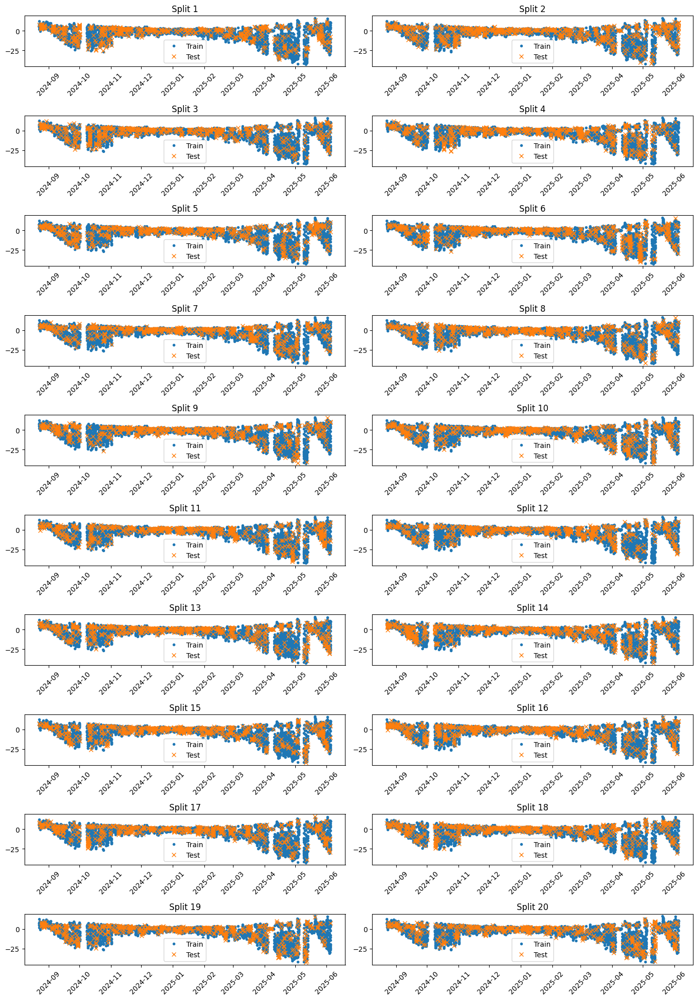

Training CV Ensemble (20 folds) & generating OOF predictions...


----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: NEE_L3.3_CUT_16_QCF0
  RMSE:   1.6279
  MAE:    0.9940
  R2:     0.9646
----------------------------------------
Fitting final model on full training set...


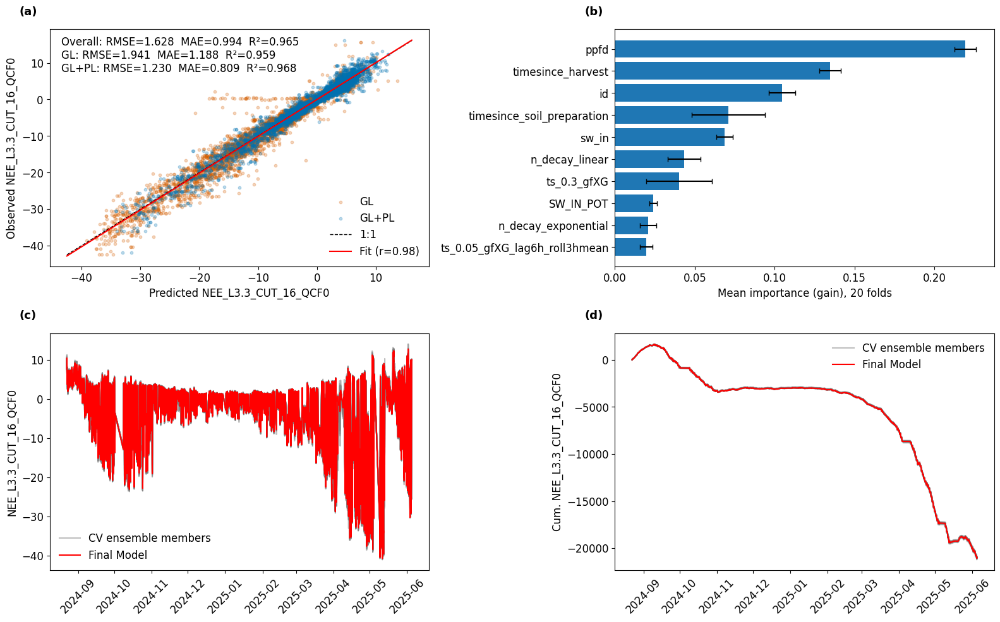

Finished training. Ensemble size (folds): 20


In [7]:
# Train ONE model to gapfill --> we train only one model for both parcels and both QCF and QCF0
print("Started training of the gapfilling model and compute gapfilling uncertainty...")
fit = fit_gapfill_ts(
    data_main,
    target_col=TARGET,
    feature_cols=selected_features,
    model_factory=model_factory,
    log_transform=LOG_TRANSFORM,      
    undersample=UNDERSAMPLE,    
    plot=False
)
print(f"Finished training. Ensemble size (folds): {len(fit.ensemble_models)}")

# Train ONE model to gapfill the footprint if only confident assignments were used before
if PARCEL_CERTAIN:
    # we train only one model for both parcels and both QCF and QCF0
    print("\nStarted training of the gapfilling model for the full footprint and compute gapfilling uncertainty...")
    fit_footprint = fit_gapfill_ts(
        maindf,
        target_col=TARGET,
        feature_cols=selected_features,
        model_factory=model_factory,
        log_transform=LOG_TRANSFORM,      
        undersample=UNDERSAMPLE,    
        plot=True
    )
    print(f"Finished training. Ensemble size (folds): {len(fit_footprint.ensemble_models)}")

### GAPFILLING

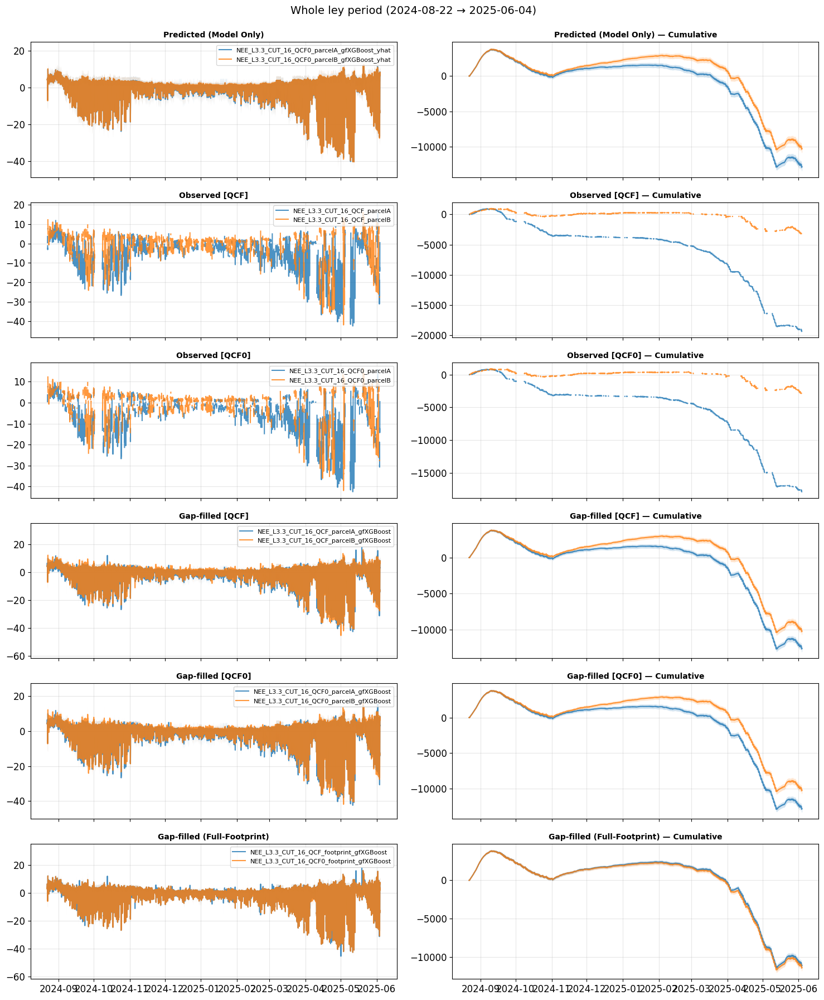

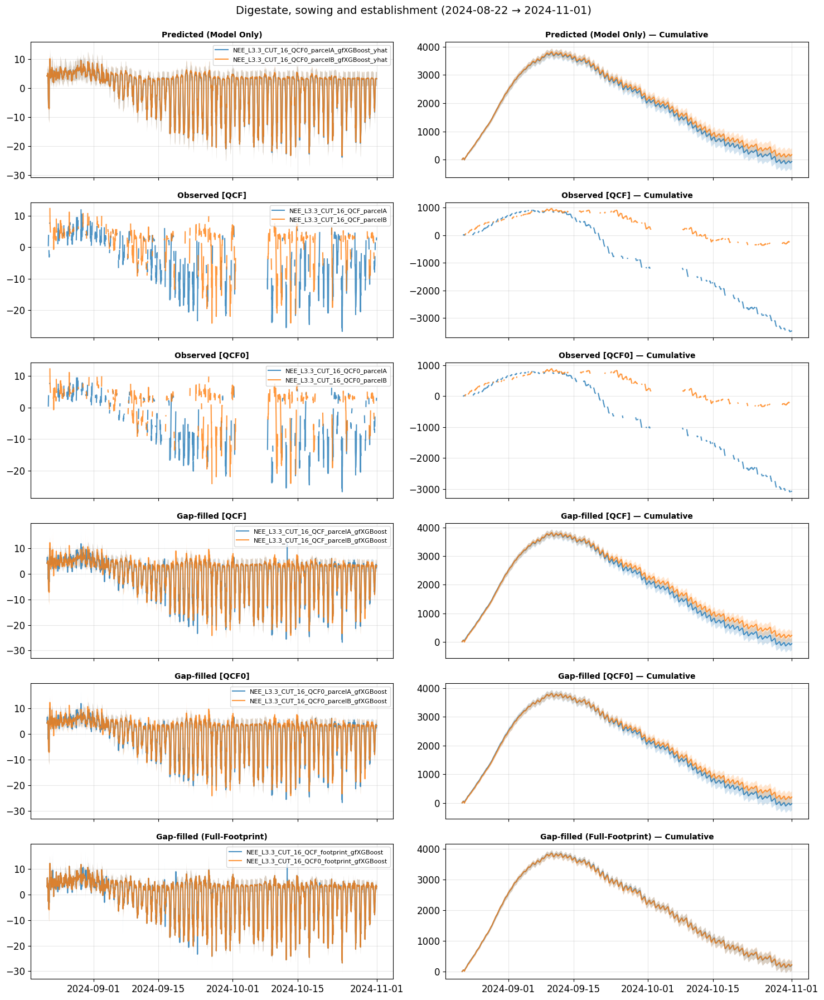

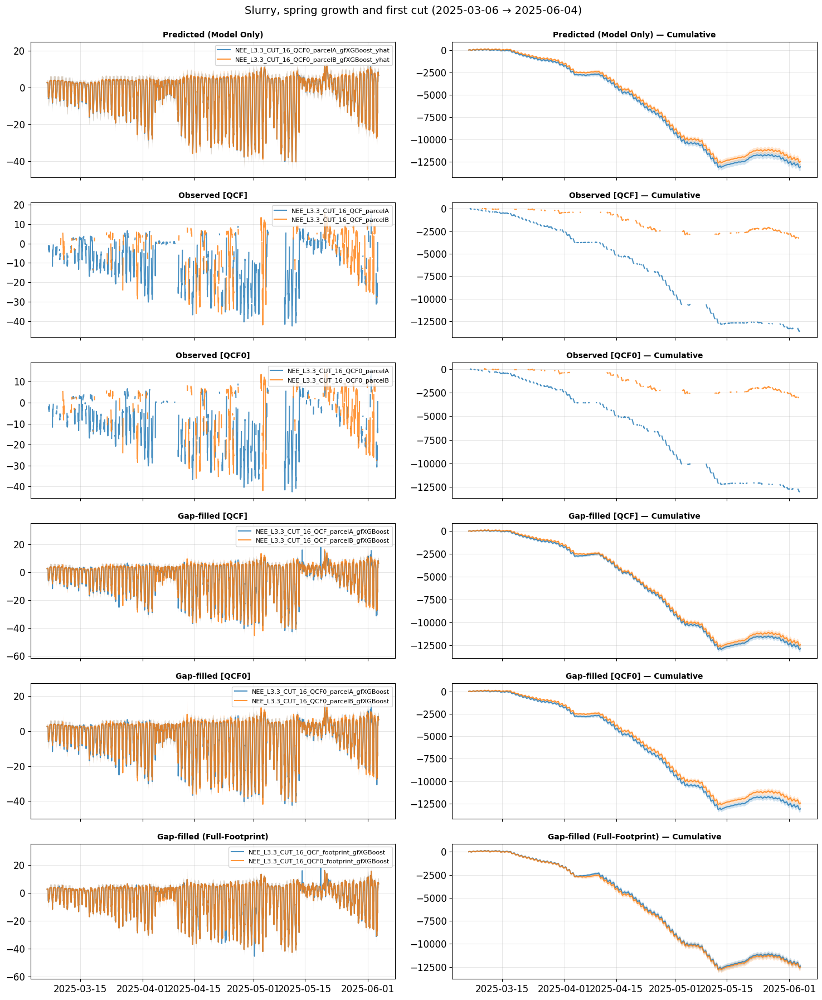

In [8]:
# Setup Views
df_fp = maindf.copy()
df_A  = build_df_for_parcel(maindf, TARGET_FLUX, "A", selected_features, add_trt=ADD_TRT)
# add FC_RANDUNC_HF because it was not included as the function includes only features starting with 'NEE' or selected features
df_A = df_A.copy()
df_A['FC_RANDUNC_HF'] = maindf['FC_RANDUNC_HF'].reindex(df_A.index)
df_B  = build_df_for_parcel(maindf, TARGET_FLUX, "B", selected_features, add_trt=ADD_TRT)
# add FC_RANDUNC_HF because it was not included as the function includes only features starting with 'NEE' or selected features
df_B = df_B.copy()
df_B['FC_RANDUNC_HF'] = maindf['FC_RANDUNC_HF'].reindex(df_B.index)

views = [
    ("parcelA", df_A, apply_gapfill_ts(df_A, fit), fit),
    ("parcelB", df_B, apply_gapfill_ts(df_B, fit), fit),
]
# Add the Footprint view
if PARCEL_CERTAIN:
    # If we trained a specific model for the footprint, use it
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit_footprint), fit_footprint))
else:
    # Otherwise, apply the only model we have
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit), fit))

# Merge Results
df_final, contexts = merge_gapfill_results(
    main_df=maindf,
    views=views,
    target=TARGET,
    target_flux=TARGET_FLUX,      # e.g. "FN2O"
    model_type=MODEL_TYPE,        # e.g. "XGBoost"
    ustar_cut=USTAR_CUT,           # e.g. "CUT_50"
    random_err_col=RAND_ERR_COL
)

# Plot Results
periods = [
    ("2024-08-22", "2025-06-04", "Whole ley period"),
    ("2024-08-22", "2024-11-01", "Digestate, sowing and establishment"),
    ("2025-03-06", "2025-06-04", "Slurry, spring growth and first cut")
]
plot_gapfill_dashboard(
    df=df_final,
    periods=periods,
    target_flux=TARGET_FLUX,
    target=TARGET,
    model_type=MODEL_TYPE,
    ustar_cut=USTAR_CUT,
    contexts=contexts
)

# Create a copy of the final dataframe for CUT16
df_CUT16 = df_final.copy()

## CUT-50

In [9]:
USTAR_CUT = 'CUT_50'
TARGET = f'{TARGET_FLUX}_L3.3_{USTAR_CUT}_QCF0'
print(f'The target variable is {TARGET}')

The target variable is NEE_L3.3_CUT_50_QCF0


### MODEL TRAINING

Started training of the gapfilling model and compute gapfilling uncertainty...


  Gap distribution: fitted mixture (cvm distance 0.9924; raw baseline 14.6242)


CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.104
  Coverage: 679/5664 rows never held out (12.0%); mean times held out 2.01
Training CV Ensemble (20 folds) & generating OOF predictions...


----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: NEE_L3.3_CUT_50_QCF0
  RMSE:   1.6731
  MAE:    1.0338
  R2:     0.9641
----------------------------------------
Fitting final model on full training set...


Finished training. Ensemble size (folds): 20

Started training of the gapfilling model for the full footprint and compute gapfilling uncertainty...


  Gap distribution: fitted mixture (cvm distance 1.8083; raw baseline 16.4885)


CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.102
  Coverage: 799/6487 rows never held out (12.3%); mean times held out 2.02


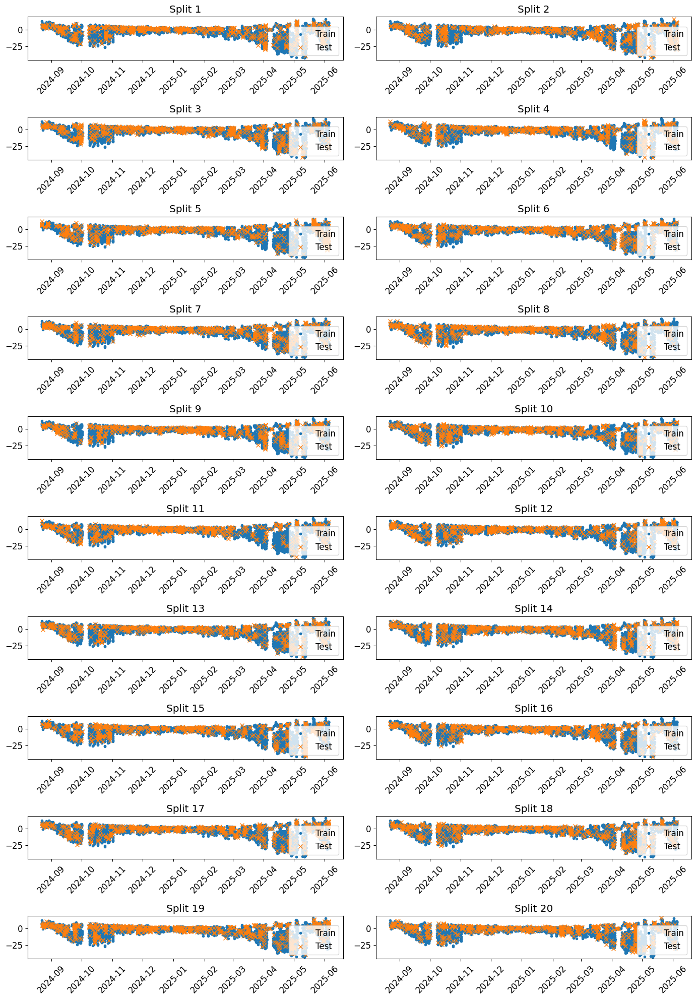

Training CV Ensemble (20 folds) & generating OOF predictions...


----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: NEE_L3.3_CUT_50_QCF0
  RMSE:   1.6438
  MAE:    1.0324
  R2:     0.9647
----------------------------------------
Fitting final model on full training set...


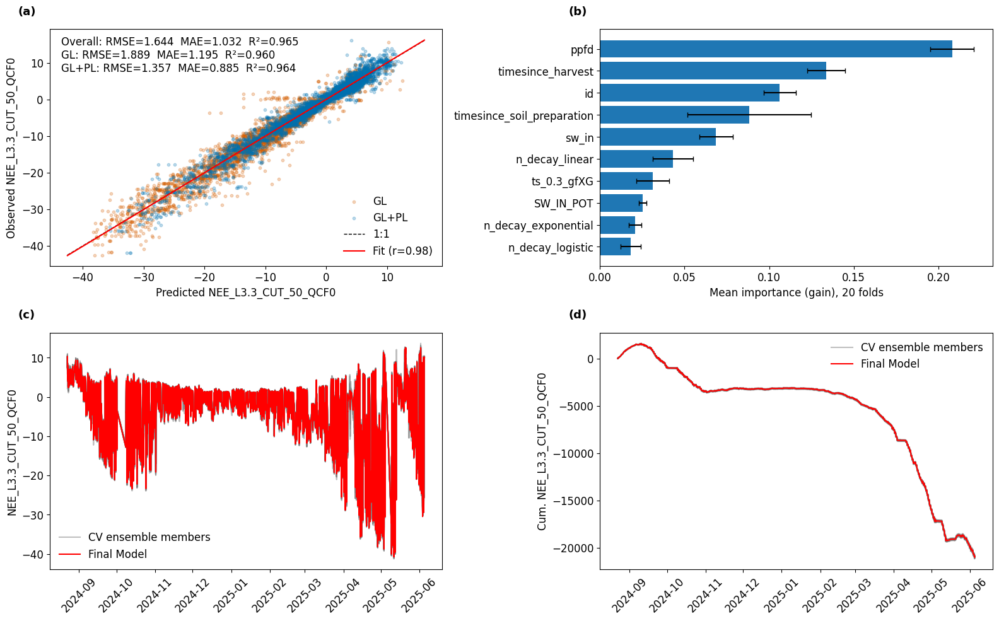

Finished training. Ensemble size (folds): 20


In [10]:
# Train ONE model to gapfill --> we train only one model for both parcels and both QCF and QCF0
print("Started training of the gapfilling model and compute gapfilling uncertainty...")
fit = fit_gapfill_ts(
    data_main,
    target_col=TARGET,
    feature_cols=selected_features,
    model_factory=model_factory,
    log_transform=LOG_TRANSFORM,      
    undersample=UNDERSAMPLE,    
    plot=False
)
print(f"Finished training. Ensemble size (folds): {len(fit.ensemble_models)}")

# Train ONE model to gapfill the footprint if only confident assignments were used before
if PARCEL_CERTAIN:
    # we train only one model for both parcels and both QCF and QCF0
    print("\nStarted training of the gapfilling model for the full footprint and compute gapfilling uncertainty...")
    fit_footprint = fit_gapfill_ts(
        maindf,
        target_col=TARGET,
        feature_cols=selected_features,
        model_factory=model_factory,
        log_transform=LOG_TRANSFORM,      
        undersample=UNDERSAMPLE,    
        plot=True
    )
    print(f"Finished training. Ensemble size (folds): {len(fit_footprint.ensemble_models)}")

### GAPFILLING

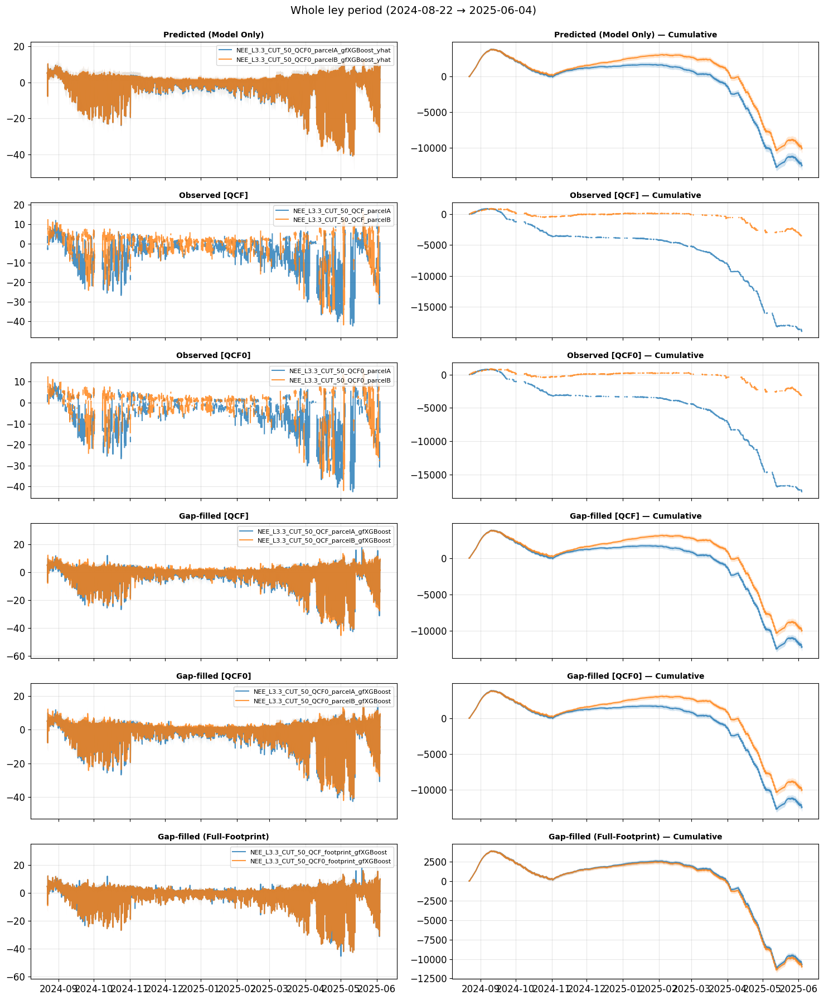

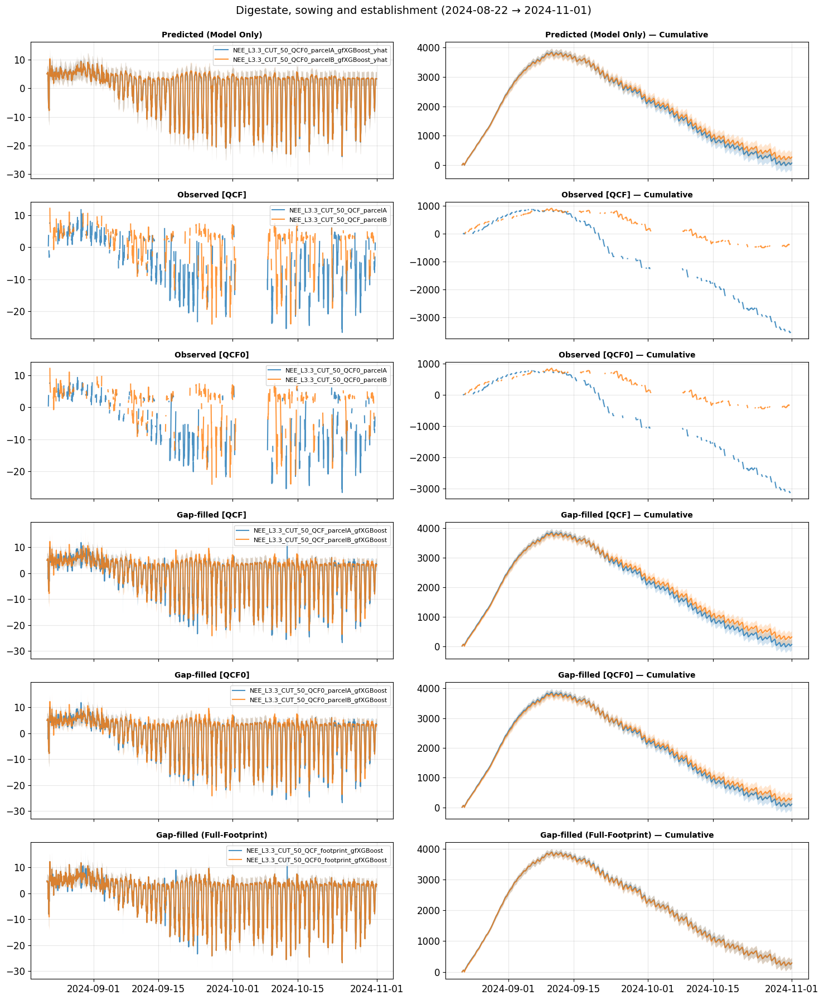

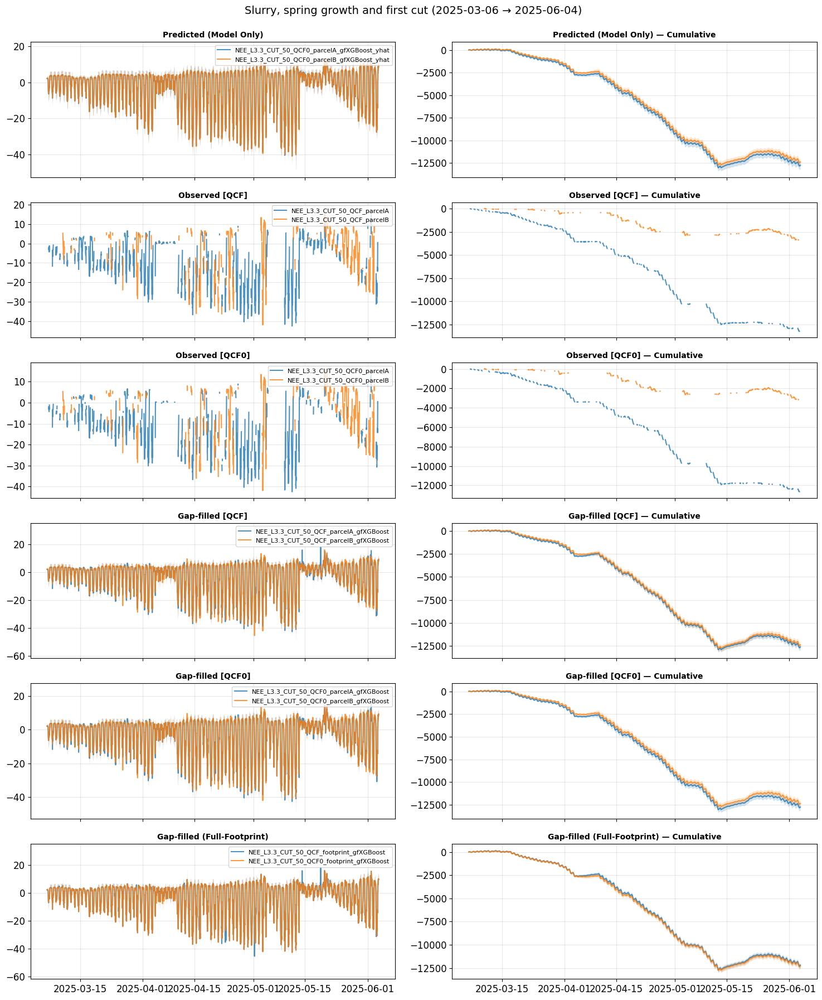

In [11]:
# Setup Views
df_fp = maindf.copy()
df_A  = build_df_for_parcel(maindf, TARGET_FLUX, "A", selected_features, add_trt=ADD_TRT)
# add FC_RANDUNC_HF because it was not included as the function includes only features starting with 'NEE' or selected features
df_A = df_A.copy()
df_A['FC_RANDUNC_HF'] = maindf['FC_RANDUNC_HF'].reindex(df_A.index)
df_B  = build_df_for_parcel(maindf, TARGET_FLUX, "B", selected_features, add_trt=ADD_TRT)
# add FC_RANDUNC_HF because it was not included as the function includes only features starting with 'NEE' or selected features
df_B = df_B.copy()
df_B['FC_RANDUNC_HF'] = maindf['FC_RANDUNC_HF'].reindex(df_B.index)
views = [
    ("parcelA", df_A, apply_gapfill_ts(df_A, fit), fit),
    ("parcelB", df_B, apply_gapfill_ts(df_B, fit), fit),
]
# Add the Footprint view
if PARCEL_CERTAIN:
    # If we trained a specific model for the footprint, use it
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit_footprint), fit_footprint))
else:
    # Otherwise, apply the only model we have
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit), fit))

# Merge Results
df_final, contexts = merge_gapfill_results(
    main_df=maindf,
    views=views,
    target_flux=TARGET_FLUX,      # e.g. "FN2O"
    target=TARGET,
    model_type=MODEL_TYPE,        # e.g. "XGBoost"
    ustar_cut=USTAR_CUT,           # e.g. "CUT_50"
    random_err_col=RAND_ERR_COL
)

# Plot Results
periods = [
    ("2024-08-22", "2025-06-04", "Whole ley period"),
    ("2024-08-22", "2024-11-01", "Digestate, sowing and establishment"),
    ("2025-03-06", "2025-06-04", "Slurry, spring growth and first cut")
]
plot_gapfill_dashboard(
    df=df_final,
    periods=periods,
    target_flux=TARGET_FLUX,
    target=TARGET,
    model_type=MODEL_TYPE,
    ustar_cut=USTAR_CUT,
    contexts=contexts
)

# Create a copy of the final dataframe for CUT50
df_CUT50 = df_final.copy()

### SHAP CHECK

  3%|=                   | 376/11498 [00:11<05:25]       

  4%|=                   | 412/11498 [00:12<05:22]       

  4%|=                   | 450/11498 [00:13<05:19]       

  4%|=                   | 484/11498 [00:14<05:18]       

  5%|=                   | 522/11498 [00:15<05:15]       

...

 98%|===================| 11303/11498 [04:24<00:04]       

 99%|===================| 11342/11498 [04:25<00:03]       

 99%|===================| 11384/11498 [04:26<00:02]       

 99%|===================| 11420/11498 [04:27<00:01]       

100%|===================| 11465/11498 [04:28<00:00]       

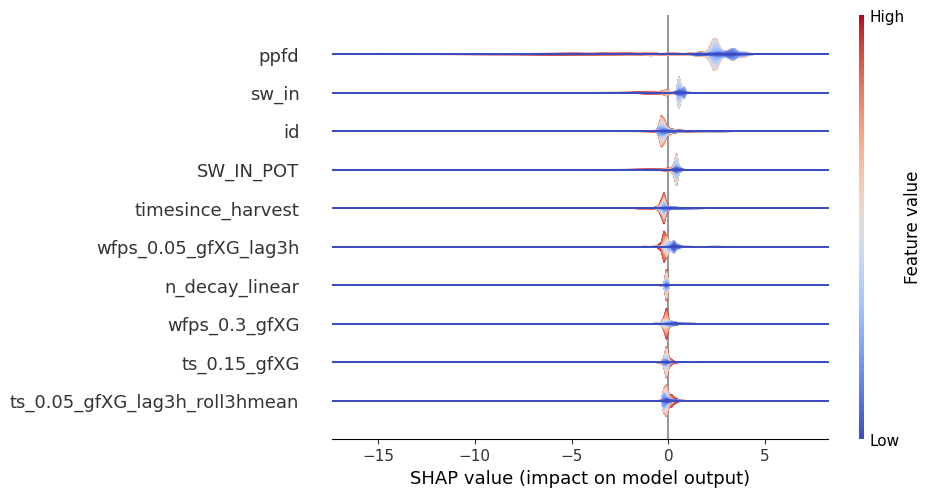

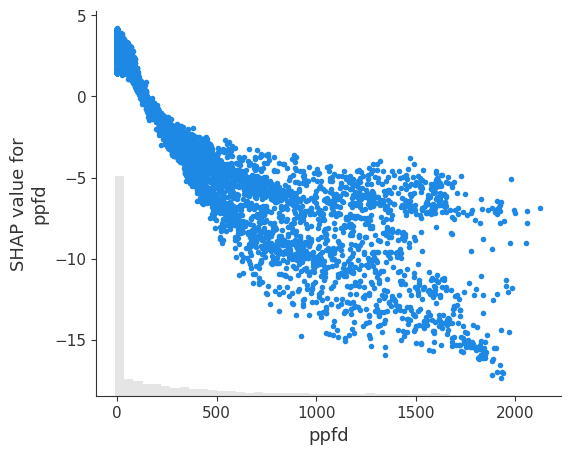

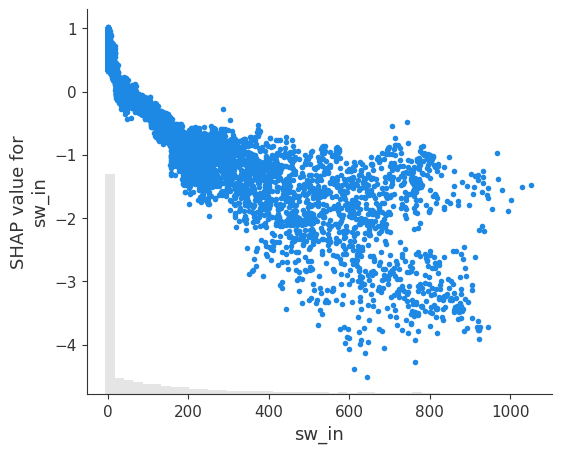

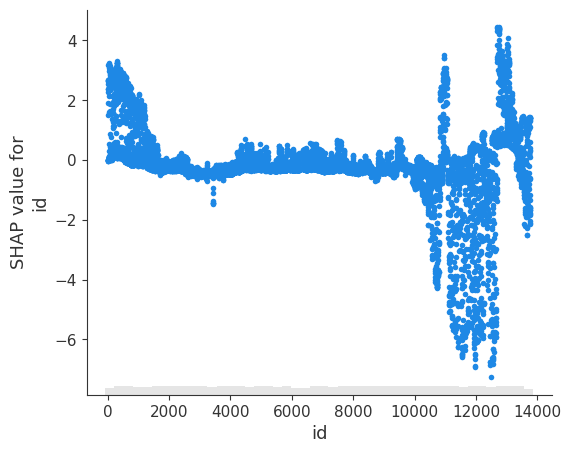

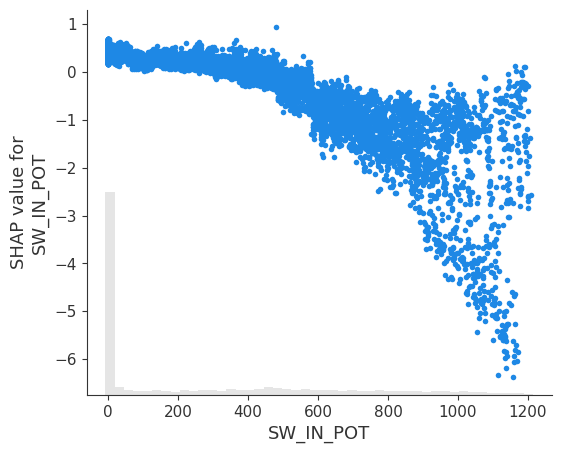

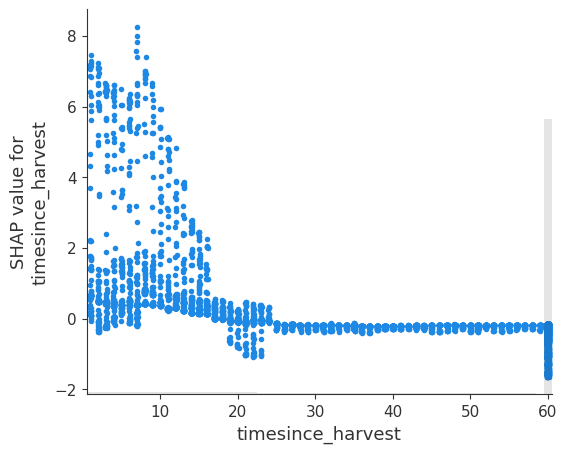

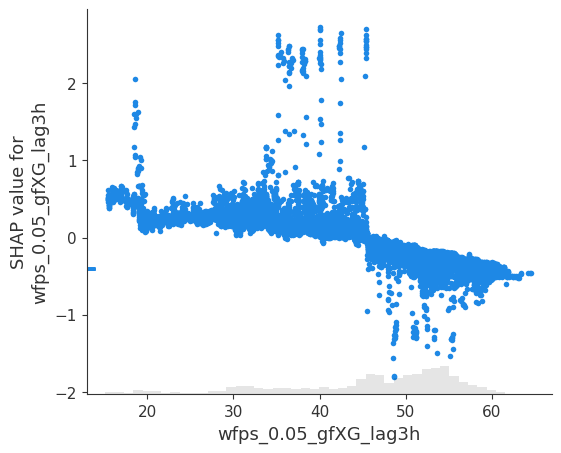

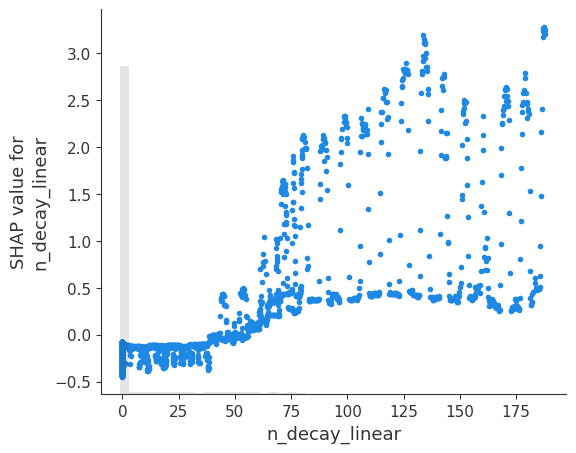

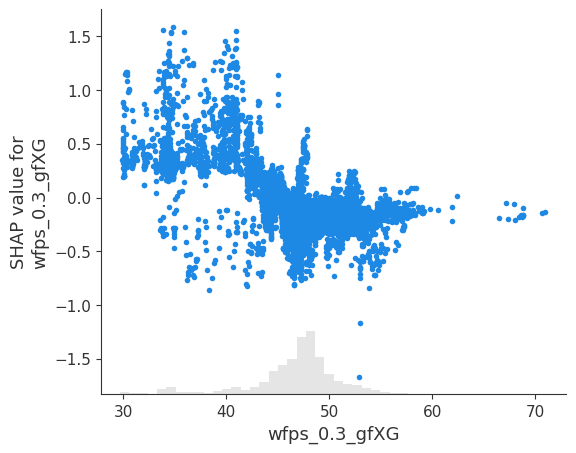

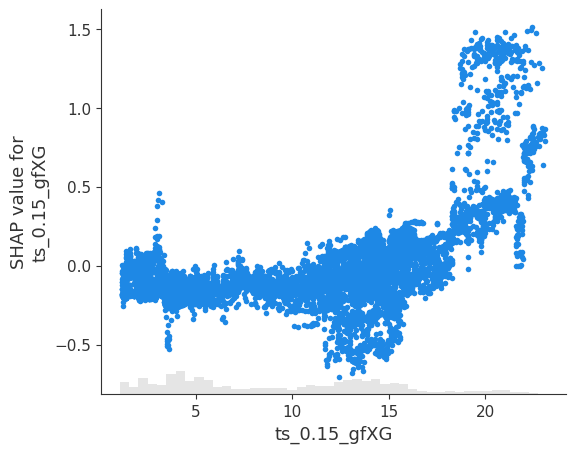

In [12]:
if SHAP_CHECK:

    # Initialize the SHAP explainer
    X = data_main[selected_features]
    explainer = shap.TreeExplainer(fit.model_final, data=X)

    # Calculate SHAP values
    shap_values = explainer(X, check_additivity=True)

    # Violin summary plot for top 10 features
    shap.plots.violin(shap_values, features=X, plot_type="layered_violin", max_display=10)
    plt.show()

    # Scatter plots of top 10 most important features
    for i in range(-1, -10, -1):
        shap.plots.scatter(shap_values[:, shap_values.abs.mean(0).argsort[i]])
        plt.show()

## CUT-84

In [13]:
USTAR_CUT = 'CUT_84'
TARGET = f'{TARGET_FLUX}_L3.3_{USTAR_CUT}_QCF0'
print(f'The target variable is {TARGET}')

The target variable is NEE_L3.3_CUT_84_QCF0


### MODEL TRAINING

Started training of the gapfilling model and compute gapfilling uncertainty...


  Gap distribution: fitted mixture (cvm distance 0.9158; raw baseline 10.3228)


CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.103
  Coverage: 643/5288 rows never held out (12.2%); mean times held out 2.01
Training CV Ensemble (20 folds) & generating OOF predictions...


----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: NEE_L3.3_CUT_84_QCF0
  RMSE:   1.5962
  MAE:    0.9920
  R2:     0.9692
----------------------------------------
Fitting final model on full training set...


Finished training. Ensemble size (folds): 20

Started training of the gapfilling model for the full footprint and compute gapfilling uncertainty...


  Gap distribution: fitted mixture (cvm distance 0.9939; raw baseline 11.6723)


CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.104
  Coverage: 723/6030 rows never held out (12.0%); mean times held out 2.02


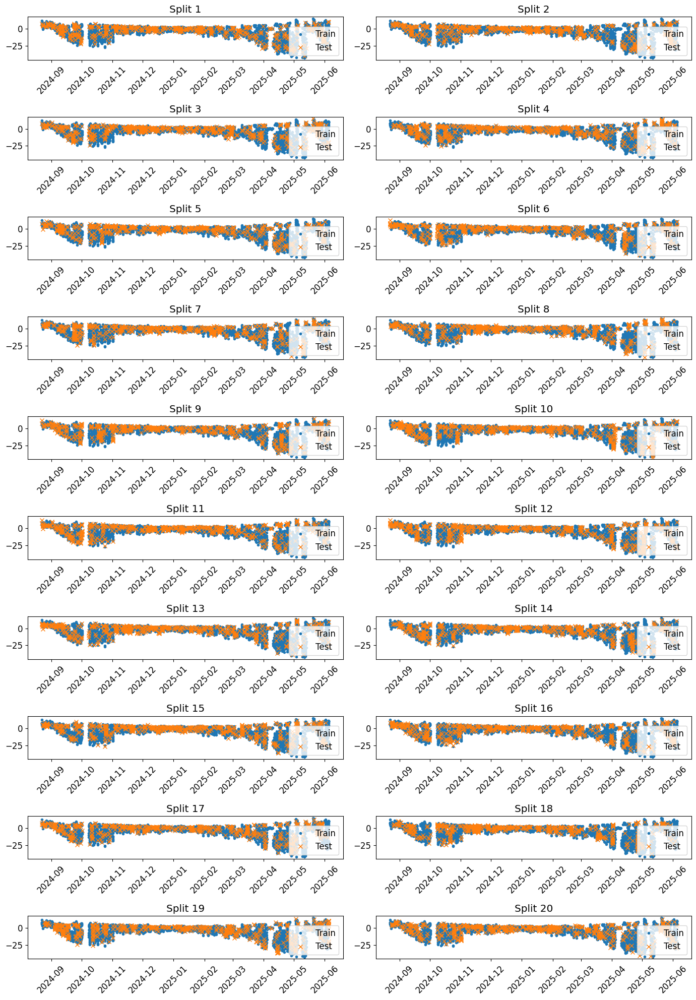

Training CV Ensemble (20 folds) & generating OOF predictions...


----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: NEE_L3.3_CUT_84_QCF0
  RMSE:   1.6741
  MAE:    1.0400
  R2:     0.9635
----------------------------------------
Fitting final model on full training set...


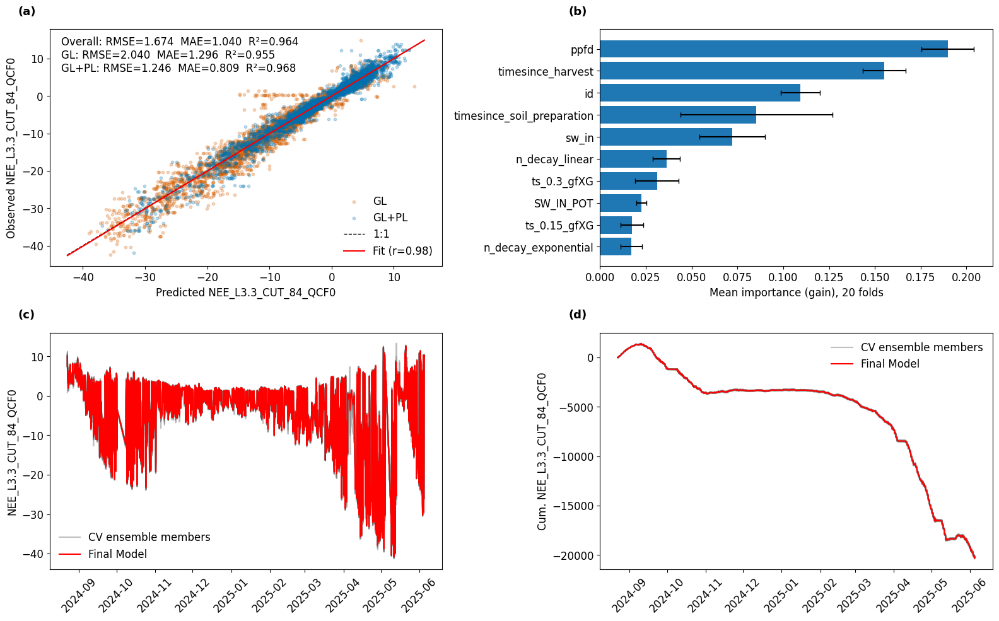

Finished training. Ensemble size (folds): 20


In [14]:
# Train ONE model to gapfill --> we train only one model for both parcels and both QCF and QCF0
print("Started training of the gapfilling model and compute gapfilling uncertainty...")
fit = fit_gapfill_ts(
    data_main,
    target_col=TARGET,
    feature_cols=selected_features,
    model_factory=model_factory,
    log_transform=LOG_TRANSFORM,      
    undersample=UNDERSAMPLE,    
    plot=False
)
print(f"Finished training. Ensemble size (folds): {len(fit.ensemble_models)}")

# Train ONE model to gapfill the footprint if only confident assignments were used before
if PARCEL_CERTAIN:
    # we train only one model for both parcels and both QCF and QCF0
    print("\nStarted training of the gapfilling model for the full footprint and compute gapfilling uncertainty...")
    fit_footprint = fit_gapfill_ts(
        maindf,
        target_col=TARGET,
        feature_cols=selected_features,
        model_factory=model_factory,
        log_transform=LOG_TRANSFORM,      
        undersample=UNDERSAMPLE,    
        plot=True
    )
    print(f"Finished training. Ensemble size (folds): {len(fit_footprint.ensemble_models)}")

### GAPFILLING

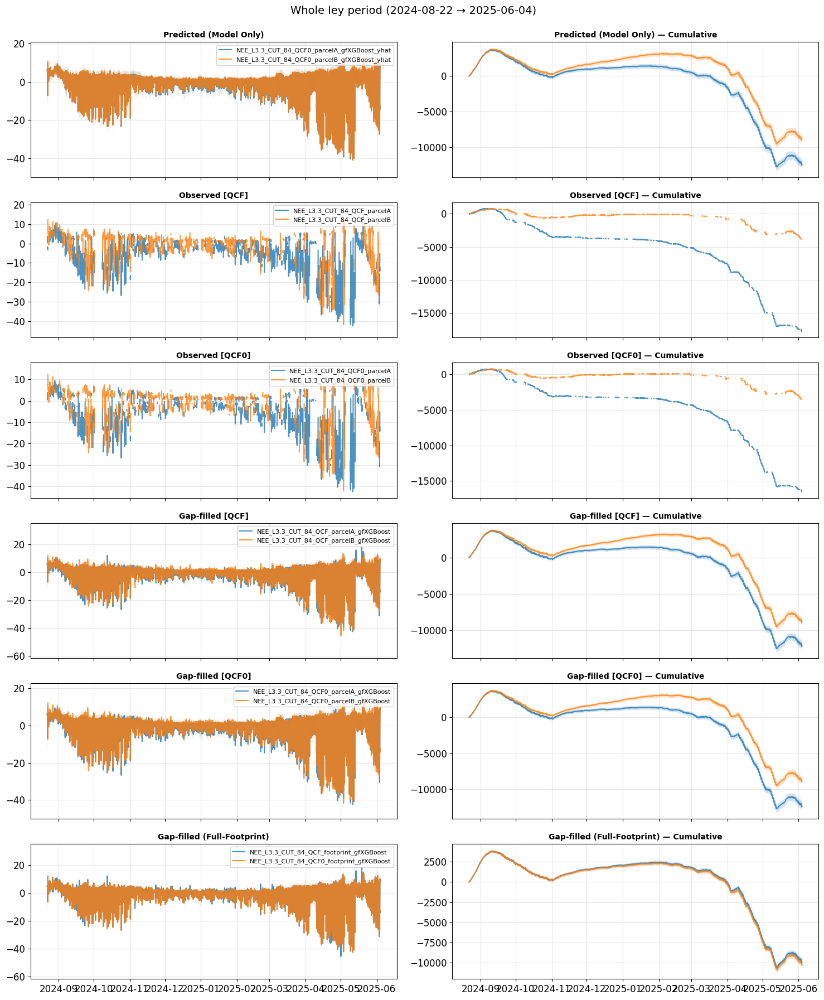

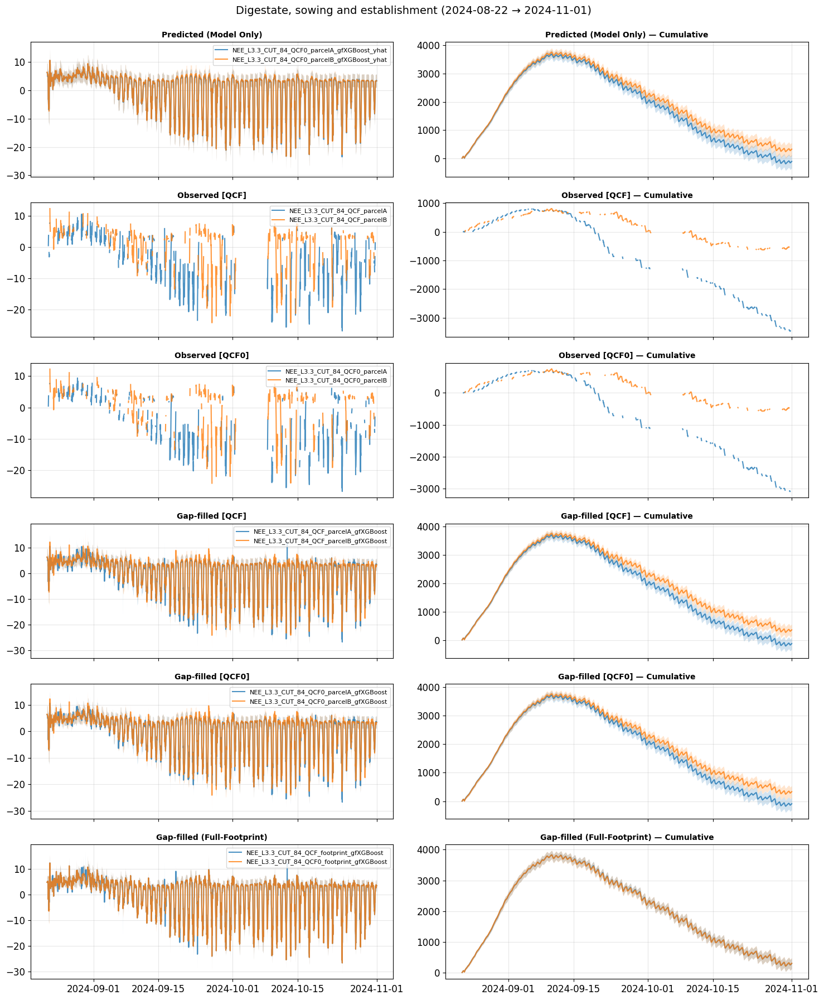

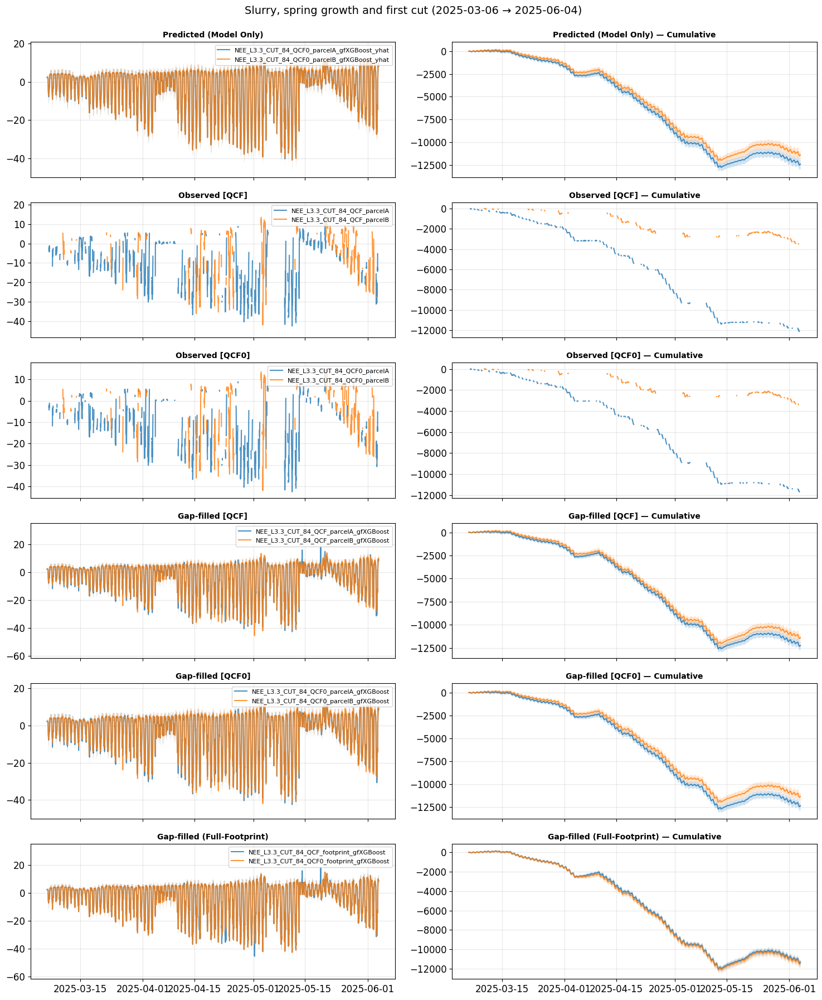

In [15]:
# Setup Views
df_fp = maindf.copy()
df_A  = build_df_for_parcel(maindf, TARGET_FLUX, "A", selected_features, add_trt=ADD_TRT)
# add FC_RANDUNC_HF because it was not included as the function includes only features starting with 'NEE' or selected features
df_A = df_A.copy()
df_A['FC_RANDUNC_HF'] = maindf['FC_RANDUNC_HF'].reindex(df_A.index)
df_B  = build_df_for_parcel(maindf, TARGET_FLUX, "B", selected_features, add_trt=ADD_TRT)
# add FC_RANDUNC_HF because it was not included as the function includes only features starting with 'NEE' or selected features
df_B = df_B.copy()
df_B['FC_RANDUNC_HF'] = maindf['FC_RANDUNC_HF'].reindex(df_B.index)
views = [
    ("parcelA", df_A, apply_gapfill_ts(df_A, fit), fit),
    ("parcelB", df_B, apply_gapfill_ts(df_B, fit), fit),
]
# Add the Footprint view
if PARCEL_CERTAIN:
    # If we trained a specific model for the footprint, use it
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit_footprint), fit_footprint))
else:
    # Otherwise, apply the only model we have
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit), fit))

# Merge Results
df_final, contexts = merge_gapfill_results(
    main_df=maindf,
    views=views,
    target_flux=TARGET_FLUX,      # e.g. "FN2O"
    target=TARGET,
    model_type=MODEL_TYPE,        # e.g. "XGBoost"
    ustar_cut=USTAR_CUT,           # e.g. "CUT_50"
    random_err_col=RAND_ERR_COL
)

# Plot Results
periods = [
    ("2024-08-22", "2025-06-04", "Whole ley period"),
    ("2024-08-22", "2024-11-01", "Digestate, sowing and establishment"),
    ("2025-03-06", "2025-06-04", "Slurry, spring growth and first cut")
]
plot_gapfill_dashboard(
    df=df_final,
    periods=periods,
    target_flux=TARGET_FLUX,
    target=TARGET,
    model_type=MODEL_TYPE,
    ustar_cut=USTAR_CUT,
    contexts=contexts
)

# Create a copy of the final dataframe for CUT84
df_CUT84 = df_final.copy()

# MERGE RESULTS

In [16]:
newcols_CUT16 = [c for c in df_CUT16.columns if c not in maindf]
print(f"NEW VARIABLES FROM GAP-FILLING {TARGET}:")
display(newcols_CUT16)

newcols_CUT50 = [c for c in df_CUT50.columns if c not in maindf]
print(f"NEW VARIABLES FROM GAP-FILLING {TARGET}:")  
display(newcols_CUT50)

newcols_CUT84 = [c for c in df_CUT84.columns if c not in maindf]
print(f"NEW VARIABLES FROM GAP-FILLING {TARGET}:")     
display(newcols_CUT84)

# Merge the new columns into a single dataframe
gapfilled_df = pd.concat([df_CUT16[newcols_CUT16], df_CUT50[newcols_CUT50], df_CUT84[newcols_CUT84]], axis=1)

gapfilled_df

NEW VARIABLES FROM GAP-FILLING NEE_L3.3_CUT_84_QCF0:


['NEE_L3.3_CUT_16_QCF_parcelA',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_yhat',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost',
 'FLAG_NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ISFILLED',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaGF',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaResid',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaEns',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_total_unc',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaObs',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens00',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens01',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens02',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens03',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens04',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens05',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens06',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens07',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens08',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens09',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens10',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoos

NEW VARIABLES FROM GAP-FILLING NEE_L3.3_CUT_84_QCF0:


['NEE_L3.3_CUT_50_QCF_parcelA',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_yhat',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost',
 'FLAG_NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ISFILLED',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaGF',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaResid',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaEns',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_total_unc',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaObs',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens00',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens01',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens02',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens03',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens04',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens05',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens06',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens07',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens08',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens09',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens10',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoos

NEW VARIABLES FROM GAP-FILLING NEE_L3.3_CUT_84_QCF0:


['NEE_L3.3_CUT_84_QCF_parcelA',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_yhat',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost',
 'FLAG_NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ISFILLED',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaGF',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaResid',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaEns',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_total_unc',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaObs',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens00',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens01',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens02',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens03',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens04',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens05',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens06',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens07',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens08',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens09',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens10',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoos

,NEE_L3.3_CUT_16_QCF_parcelA,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_yhat,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost,FLAG_NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ISFILLED,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaGF,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaResid,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaEns,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_total_unc,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaObs,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens00,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens01,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens02,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens03,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens04,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens05,...,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens05,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens06,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens07,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens08,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens09,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens10,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens11,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens12,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens13,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens14,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens15,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens16,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens17,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens18,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens19
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-08-22 00:15:00,NaN,4.248613,4.248613,1,1.348340,1.242112,0.524575,1.348340,1.468070,5.632235,5.166770,5.441307,5.288424,5.399285,5.219240,...,5.669019,5.061279,6.697467,5.114174,4.611203,5.479743,5.578880,5.127724,5.486167,5.406295,5.441463,5.134264,5.207870,4.458621,5.355805
2024-08-22 00:45:00,NaN,4.248613,4.248613,1,1.341988,1.242112,0.508025,1.341988,3.661990,5.632235,5.166770,5.441307,5.288424,5.375426,5.267838,...,5.493054,4.800270,6.614696,4.984047,4.542683,5.458522,5.522336,4.906122,5.534100,5.443357,5.440093,5.309669,5.001252,4.531747,5.374063
2024-08-22 01:15:00,NaN,4.248613,4.248613,1,1.341339,1.242112,0.506309,1.341339,0.965964,5.632235,5.196208,5.463774,5.265171,5.375426,5.208541,...,5.669019,4.958463,6.455025,5.114174,4.611203,5.399852,5.578880,5.164246,5.453488,5.338524,5.441463,5.134264,5.207870,4.527202,5.366464
2024-08-22 01:45:00,6.566236,4.119246,6.566236,0,1.336125,1.242112,0.492329,1.585380,1.585380,5.632235,5.196208,5.455657,5.265171,5.375426,5.239306,...,5.493054,4.840718,6.395240,4.977121,4.542683,5.350466,5.522336,4.919437,5.501421,5.336229,5.611243,5.309669,5.051096,4.600329,5.325774
2024-08-22 02:15:00,NaN,4.119246,4.119246,1,1.349985,1.242112,0.528788,1.349985,1.852140,5.586957,5.106067,5.472393,5.039294,5.281761,5.093706,...,5.493054,4.868279,6.367209,4.913272,4.542683,5.299899,5.490047,4.905828,5.352509,5.323313,5.485988,5.245954,5.044921,4.641542,5.325774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,NaN,9.784657,9.784657,1,1.728474,1.706768,0.273068,1.728474,0.510651,9.773724,9.897761,10.117984,9.943034,10.050313,9.901470,...,10.291671,10.313585,10.184143,10.205165,10.130551,10.295714,10.356476,10.397308,10.342398,10.320307,10.193606,10.241170,10.258471,9.518491,10.381469
2025-06-04 22:15:00,NaN,9.631040,9.631040,1,1.720498,1.706768,0.216928,1.720498,0.432552,9.595117,9.716796,9.686436,9.779700,9.861654,9.733327,...,9.966759,10.049745,9.811559,9.947085,9.834920,9.990389,10.353203,10.252034,10.062006,9.955725,10.081480,10.062689,10.042943,9.379811,9.890552
2025-06-04 22:45:00,NaN,9.684240,9.684240,1,1.722199,1.706768,0.230031,1.722199,0.580992,9.497993,9.716247,9.609970,9.804771,9.784874,9.708615,...,10.002312,9.968057,9.775000,9.895196,9.955281,9.883547,10.131139,10.174637,9.933991,10.046745,10.068542,10.189172,9.957444,9.379811,10.019363


Cumulative plots to check differences between CUT16, CUT50 and CUT84

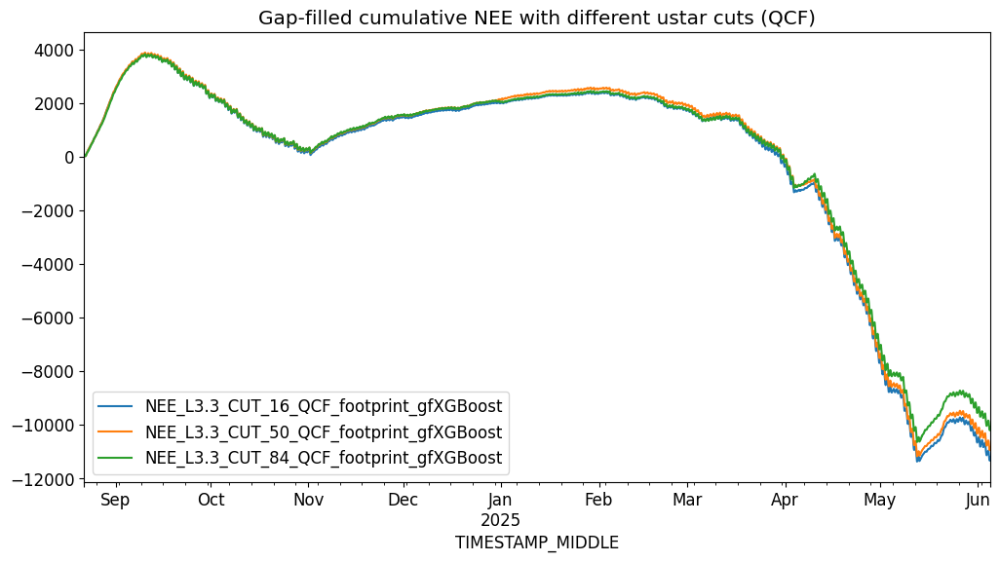

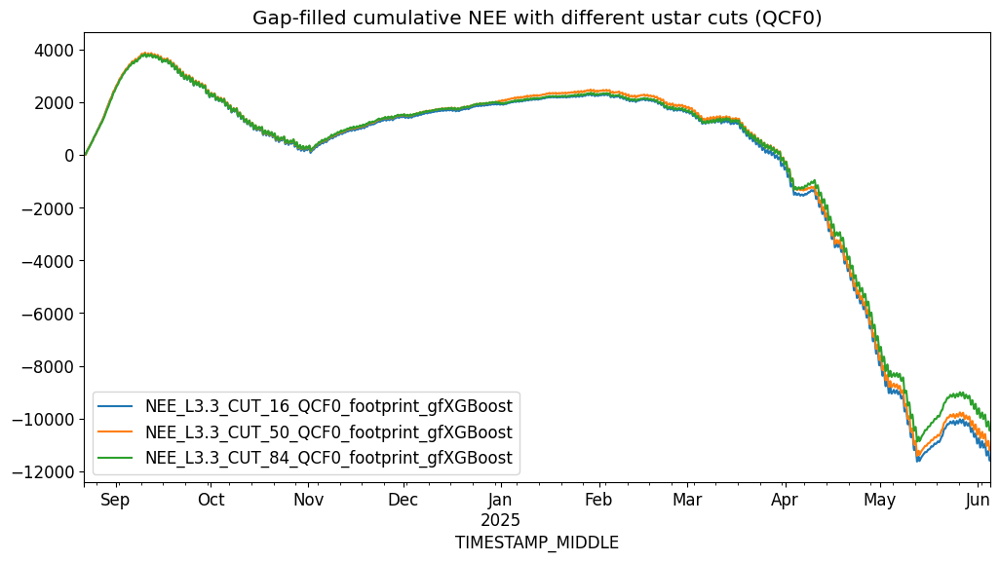

In [17]:
# Plot cumulative fluxes for different ustar cuts and QCF/QCF0
for qcf in ['QCF', 'QCF0']:
    gapfilled_df[
        [
        f'{TARGET_FLUX}_L3.3_CUT_16_{qcf}_footprint_gf{MODEL_TYPE}', 
        f'{TARGET_FLUX}_L3.3_CUT_50_{qcf}_footprint_gf{MODEL_TYPE}', 
        f'{TARGET_FLUX}_L3.3_CUT_84_{qcf}_footprint_gf{MODEL_TYPE}'
        ]].cumsum().plot(figsize=(12, 6), title=f'Gap-filled cumulative {TARGET_FLUX} with different ustar cuts ({qcf})')
    plt.show()

# EXPORT

In [18]:
filename = f"81.4.1_{TARGET_FLUX}_GF-{MODEL_TYPE}"
df_export = gapfilled_df.copy()
save_parquet(data=df_export, filename=filename)

Saved file 81.4.1_NEE_GF-XGBoost.parquet (0.886 seconds).


'81.4.1_NEE_GF-XGBoost.parquet'

Partitioning subset for ReddyProc

In [19]:
from diive.core.times.times import insert_timestamp
meteo = load_parquet(filepath=r"../../10_METEO/13.1_CH-TAN_meteo_gapfilled.parquet")
fluxes = load_parquet(filepath=r"../../70_SPLIT_TREATMENTS/71.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC_PARCELS.parquet")
ustar = fluxes['USTAR']
meteo = meteo[['ta', 'sw_in', 'vpd', 'ppfd', 'rh']]
gapfilled_nee = df_export[newcols_CUT50].copy()
export_REddyProc = pd.concat([gapfilled_nee, meteo, ustar], axis=1)
export_REddyProc = insert_timestamp(data=export_REddyProc, convention="end", set_as_index=True)
filename = "81.4.2_PartitioningSubsetForREddyProc"
export_REddyProc.to_csv(f"{filename}.csv", index=True)
print(f"Exported {filename} for partitioning of the XGBoost-gapfilled NEE")
export_REddyProc

Loaded .parquet file ../../10_METEO/13.1_CH-TAN_meteo_gapfilled.parquet (0.013 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
Loaded .parquet file ../../70_SPLIT_TREATMENTS/71.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC_PARCELS.parquet (0.136 seconds).


    --> Detected time resolution of <30 * Minutes> / 30min 


Exported 81.4.2_PartitioningSubsetForREddyProc for partitioning of the XGBoost-gapfilled NEE


,NEE_L3.3_CUT_50_QCF_parcelA,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_yhat,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost,FLAG_NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ISFILLED,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaGF,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaResid,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaEns,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_total_unc,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaObs,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens00,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens01,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens02,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens03,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens04,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens05,...,NEE_L3.3_CUT_50_QCF0_footprint_gfXGBoost_ens11,NEE_L3.3_CUT_50_QCF0_footprint_gfXGBoost_ens12,NEE_L3.3_CUT_50_QCF0_footprint_gfXGBoost_ens13,NEE_L3.3_CUT_50_QCF0_footprint_gfXGBoost_ens14,NEE_L3.3_CUT_50_QCF0_footprint_gfXGBoost_ens15,NEE_L3.3_CUT_50_QCF0_footprint_gfXGBoost_ens16,NEE_L3.3_CUT_50_QCF0_footprint_gfXGBoost_ens17,NEE_L3.3_CUT_50_QCF0_footprint_gfXGBoost_ens18,NEE_L3.3_CUT_50_QCF0_footprint_gfXGBoost_ens19,ta,sw_in,vpd,ppfd,rh,USTAR
TIMESTAMP_END,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-08-21 23:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-08-22 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-08-22 00:30:00,NaN,5.070956,5.070956,1.0,1.343688,1.237200,0.524246,1.343688,1.468070,5.714767,4.451707,5.095552,5.181273,4.458476,5.000165,...,5.622939,5.280592,5.267090,5.272433,5.279929,5.037905,5.533989,5.537464,5.130313,11.276667,0.0,0.141369,0.0,89.440002,0.013084
2024-08-22 01:00:00,NaN,5.070956,5.070956,1.0,1.344948,1.237200,0.527467,1.344948,3.661990,5.714767,4.384789,5.056592,5.182951,4.458476,5.000165,...,5.883044,4.754724,5.072637,5.075877,5.248466,5.006383,5.408001,5.339728,4.825581,11.043333,0.0,0.130055,0.0,90.133334,0.072340
2024-08-22 01:30:00,NaN,5.106140,5.106140,1.0,1.347093,1.237200,0.532914,1.347093,0.965964,5.753355,4.384789,5.068458,5.182951,4.458476,5.000165,...,5.622939,5.235128,5.205029,5.326921,5.386911,5.037905,5.508106,5.663373,5.144673,10.890000,0.0,0.118427,0.0,90.923334,0.075366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 22:00:00,NaN,9.970266,9.970266,1.0,1.572654,1.564401,0.160903,1.572654,0.510651,9.898888,10.149756,9.941967,9.838850,9.722989,10.193448,...,10.419104,10.188137,9.259439,10.289059,10.321284,9.052761,10.315116,9.400736,10.159730,15.693333,0.0,0.308913,0.0,82.700000,0.413091
2025-06-04 22:30:00,NaN,9.884456,9.884456,1.0,1.574036,1.564401,0.173886,1.574036,0.432552,9.954169,9.907409,9.687997,9.610916,9.512979,10.023190,...,10.091350,9.962421,9.364934,10.053170,10.051342,9.532040,9.994679,9.393776,9.957911,15.516667,0.0,0.275008,0.0,84.423333,0.353844
2025-06-04 23:00:00,NaN,9.875943,9.875943,1.0,1.572796,1.564401,0.162281,1.572796,0.580992,9.928572,9.832200,9.756380,9.711328,9.657171,10.046944,...,10.036739,10.001510,9.320402,10.104059,10.083425,9.619851,10.041569,9.363340,9.959536,15.660000,0.0,0.288298,0.0,83.819999,0.409273


# End of notebook

In [20]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-10-07 14:20:05
